# Flapping Wing UAV - Comprehensive Flight Data Analysis
This notebook plots **every variable** from all simulation classes for debugging.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../plot', exist_ok=True)

csv_path = '../plot/simulation_data.csv'
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} time steps of flight data.")
print(f"Columns ({len(df.columns)}): {list(df.columns[:30])}...")

Loaded 20000 time steps of flight data.
Columns (143): ['time', 'body_pos_x', 'body_pos_y', 'body_pos_z', 'body_roll', 'body_pitch', 'body_yaw', 'body_vel_x', 'body_vel_y', 'body_vel_z', 'body_p', 'body_q', 'body_r', 'flap_angle', 'flap_rate', 'elevator', 'rudder', 'body_force_x', 'body_force_y', 'body_force_z', 'body_moment_x', 'body_moment_y', 'body_moment_z', 'strip_l_0_alpha_geom', 'strip_l_0_epsilon_ce', 'strip_l_0_alpha_e', 'strip_l_0_v_in_sq', 'strip_l_0_F_tran_x', 'strip_l_0_F_tran_z', 'strip_l_0_F_rot_z']...


---
## 1. Body Positions (Pose)

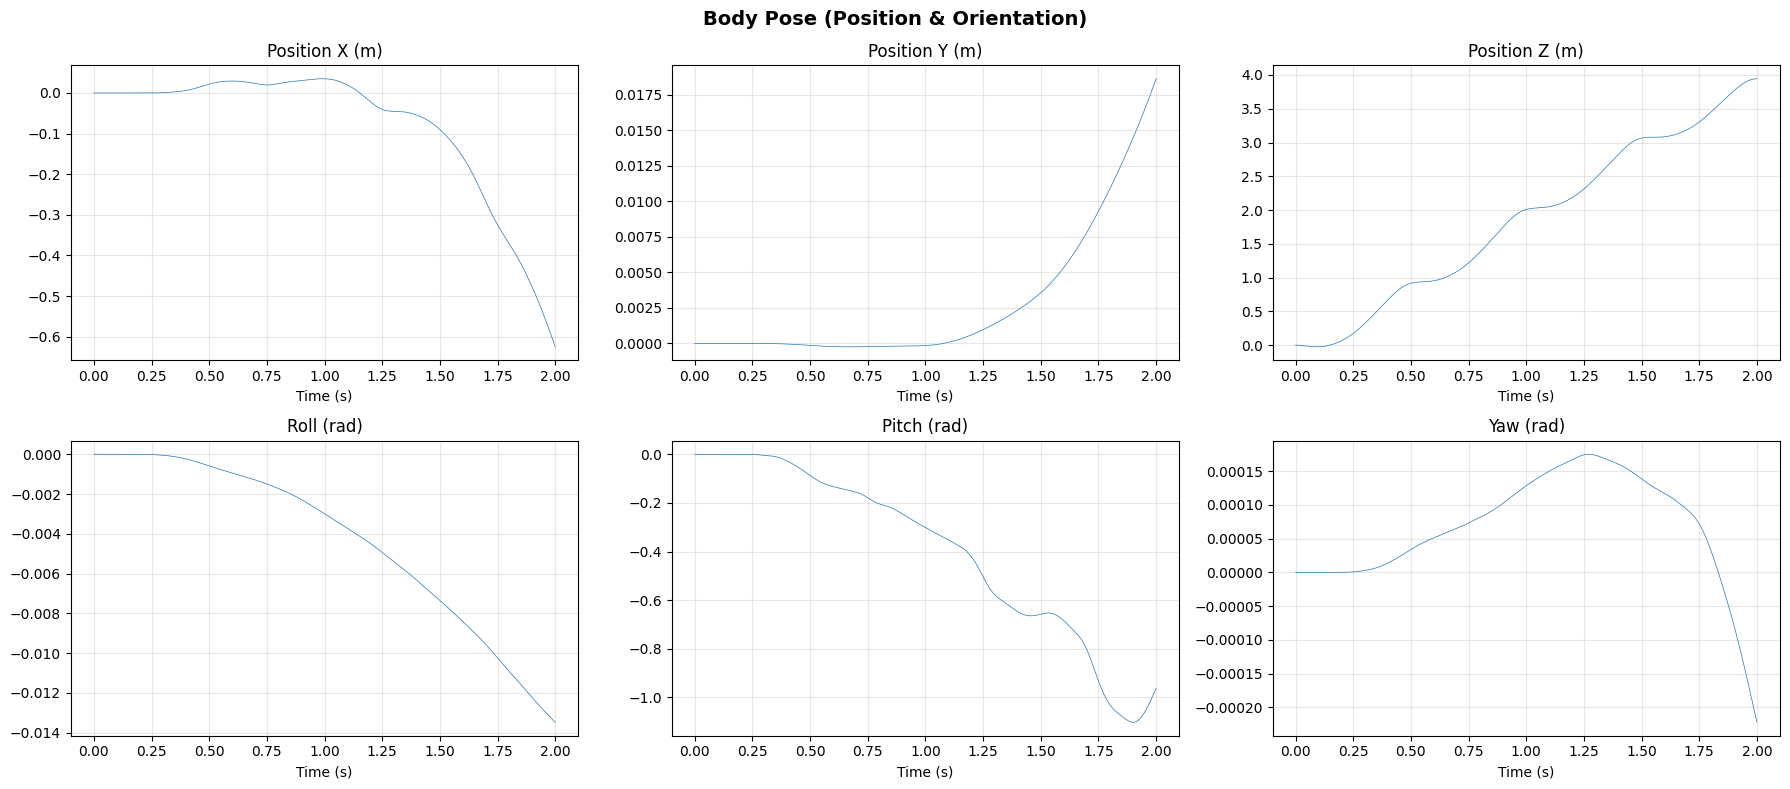

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Body Pose (Position & Orientation)', fontsize=14, fontweight='bold')

labels = ['body_pos_x', 'body_pos_y', 'body_pos_z', 'body_roll', 'body_pitch', 'body_yaw']
titles = ['Position X (m)', 'Position Y (m)', 'Position Z (m)', 'Roll (rad)', 'Pitch (rad)', 'Yaw (rad)']

for i, (label, title) in enumerate(zip(labels, titles)):
    ax = axes[i // 3][i % 3]
    if label in df.columns:
        ax.plot(df['time'], df[label], linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} - NOT FOUND')

plt.tight_layout()
plt.savefig('../plot/body_pose.png', dpi=150)
plt.show()

---
## 2. Body Velocities (State)

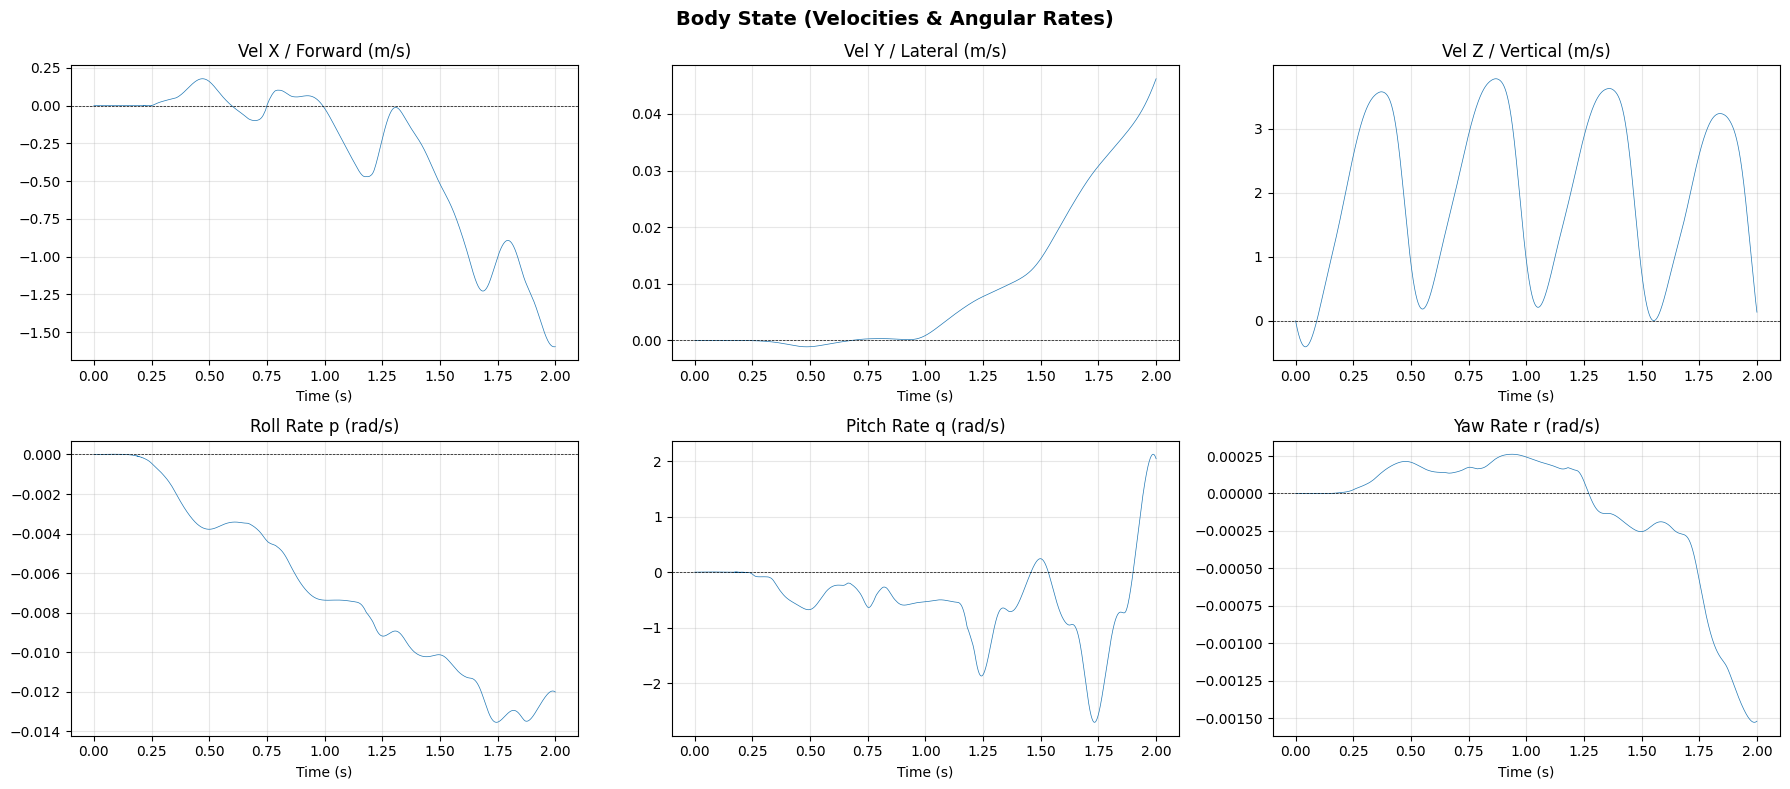

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Body State (Velocities & Angular Rates)', fontsize=14, fontweight='bold')

labels = ['body_vel_x', 'body_vel_y', 'body_vel_z', 'body_p', 'body_q', 'body_r']
titles = ['Vel X / Forward (m/s)', 'Vel Y / Lateral (m/s)', 'Vel Z / Vertical (m/s)',
          'Roll Rate p (rad/s)', 'Pitch Rate q (rad/s)', 'Yaw Rate r (rad/s)']

for i, (label, title) in enumerate(zip(labels, titles)):
    ax = axes[i // 3][i % 3]
    if label in df.columns:
        ax.plot(df['time'], df[label], linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    else:
        ax.set_title(f'{title} - NOT FOUND')

plt.tight_layout()
plt.savefig('../plot/body_velocities.png', dpi=150)
plt.show()

---
## 3. Body Forces & Moments (Wrench)

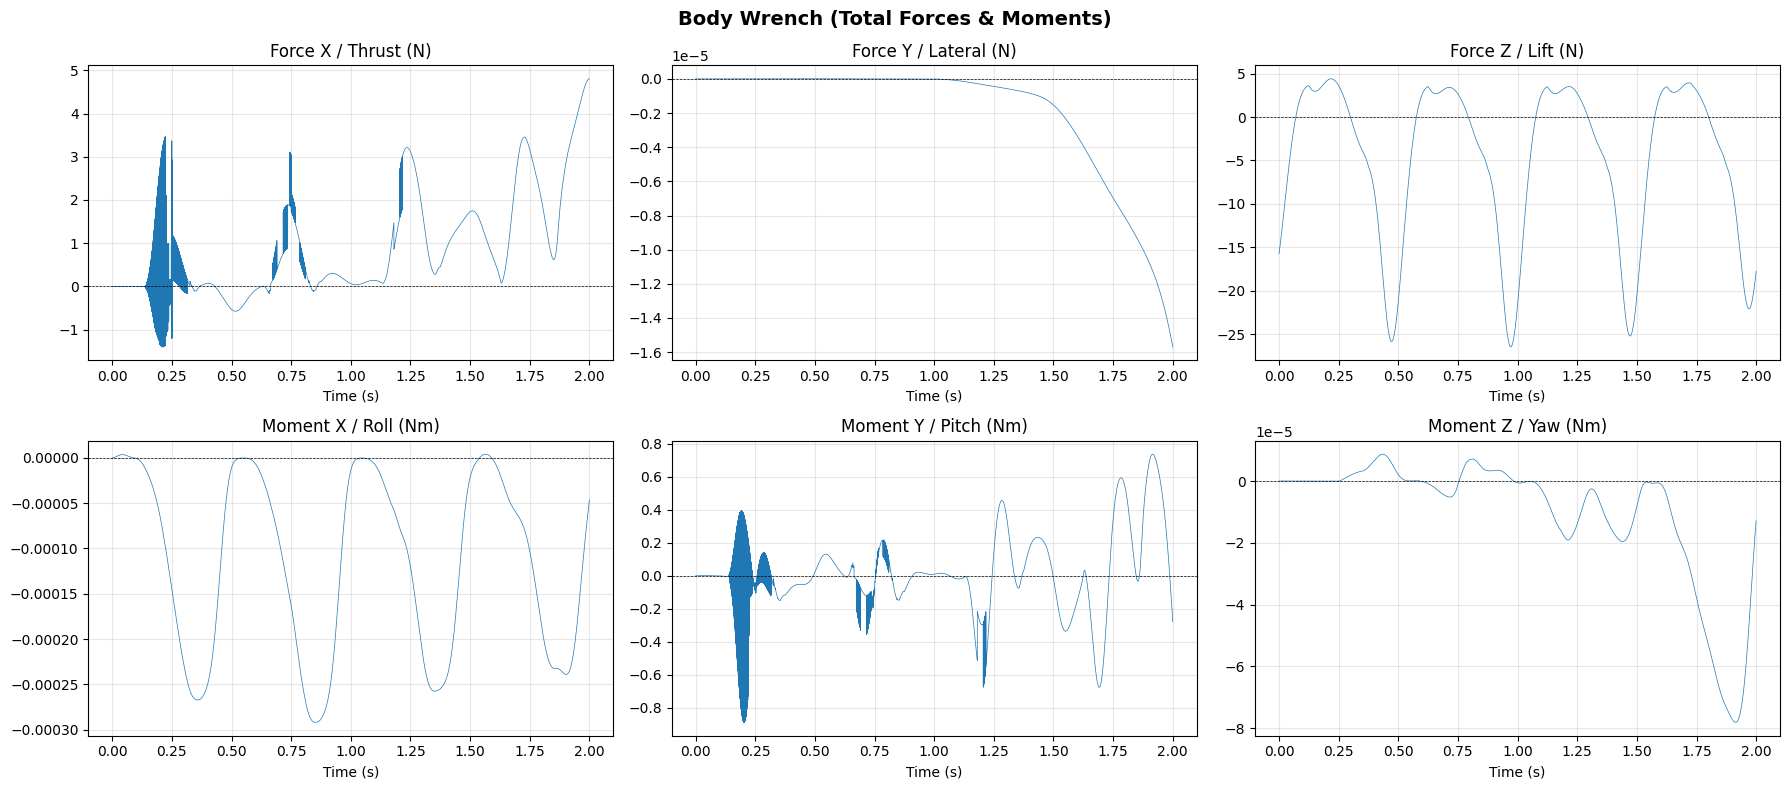

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Body Wrench (Total Forces & Moments)', fontsize=14, fontweight='bold')

labels = ['body_force_x', 'body_force_y', 'body_force_z',
          'body_moment_x', 'body_moment_y', 'body_moment_z']
titles = ['Force X / Thrust (N)', 'Force Y / Lateral (N)', 'Force Z / Lift (N)',
          'Moment X / Roll (Nm)', 'Moment Y / Pitch (Nm)', 'Moment Z / Yaw (Nm)']

for i, (label, title) in enumerate(zip(labels, titles)):
    ax = axes[i // 3][i % 3]
    if label in df.columns:
        ax.plot(df['time'], df[label], linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    else:
        ax.set_title(f'{title} - NOT FOUND')

plt.tight_layout()
plt.savefig('../plot/body_wrench.png', dpi=150)
plt.show()

---
## 4. Actuation Signals

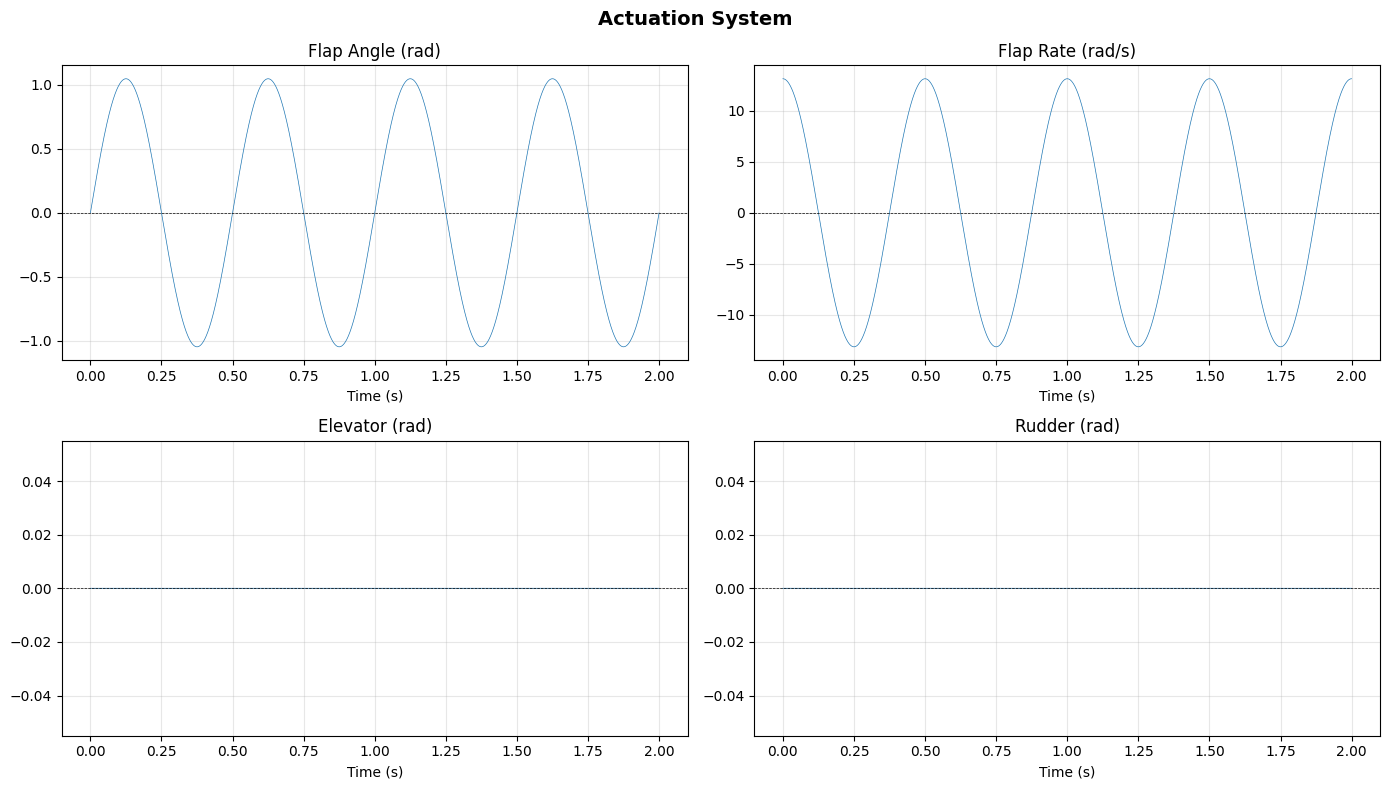

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Actuation System', fontsize=14, fontweight='bold')

labels = ['flap_angle', 'flap_rate', 'elevator', 'rudder']
titles = ['Flap Angle (rad)', 'Flap Rate (rad/s)', 'Elevator (rad)', 'Rudder (rad)']

for i, (label, title) in enumerate(zip(labels, titles)):
    ax = axes[i // 2][i % 2]
    if label in df.columns:
        ax.plot(df['time'], df[label], linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    else:
        ax.set_title(f'{title} - NOT FOUND')

plt.tight_layout()
plt.savefig('../plot/actuation.png', dpi=150)
plt.show()

---
## 5. Wing Strip Angles (Mid-span Strip 5)
Geometric AOA, passive twist (epsilon_ce), and effective AOA.

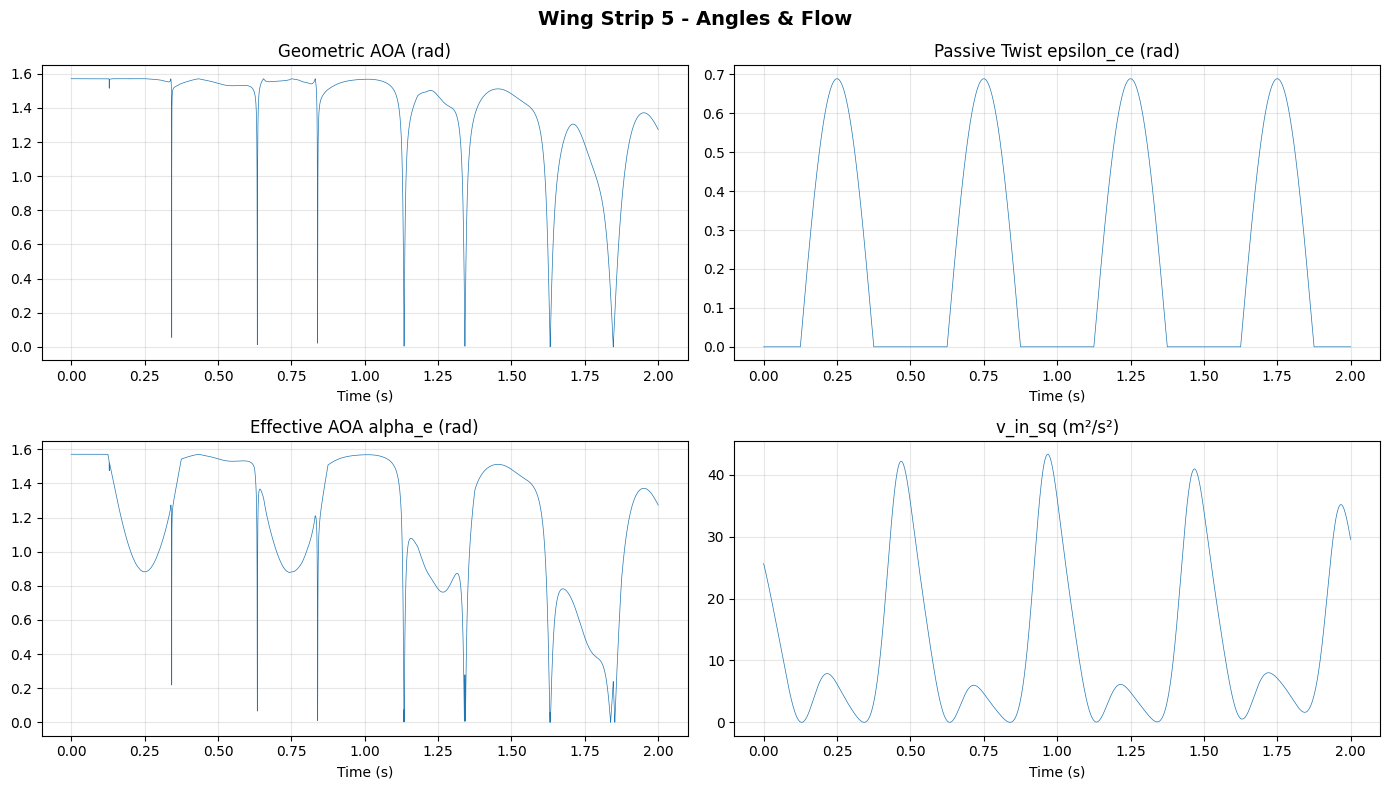

In [28]:
strip_idx = 5
prefix = f'strip_l_{strip_idx}'

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Wing Strip {strip_idx} - Angles & Flow', fontsize=14, fontweight='bold')

angle_labels = [f'{prefix}_alpha_geom', f'{prefix}_epsilon_ce', f'{prefix}_alpha_e', f'{prefix}_v_in_sq']
angle_titles = ['Geometric AOA (rad)', 'Passive Twist epsilon_ce (rad)',
                'Effective AOA alpha_e (rad)', 'v_in_sq (m²/s²)']

for i, (label, title) in enumerate(zip(angle_labels, angle_titles)):
    ax = axes[i // 2][i % 2]
    if label in df.columns:
        ax.plot(df['time'], df[label], linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} - NOT FOUND')

plt.tight_layout()
plt.savefig('../plot/strip_angles.png', dpi=150)
plt.show()

---
## 6. Wing Strip Forces (Mid-span Strip 5)
All force components: translational, rotational, added mass, inertial, and totals.

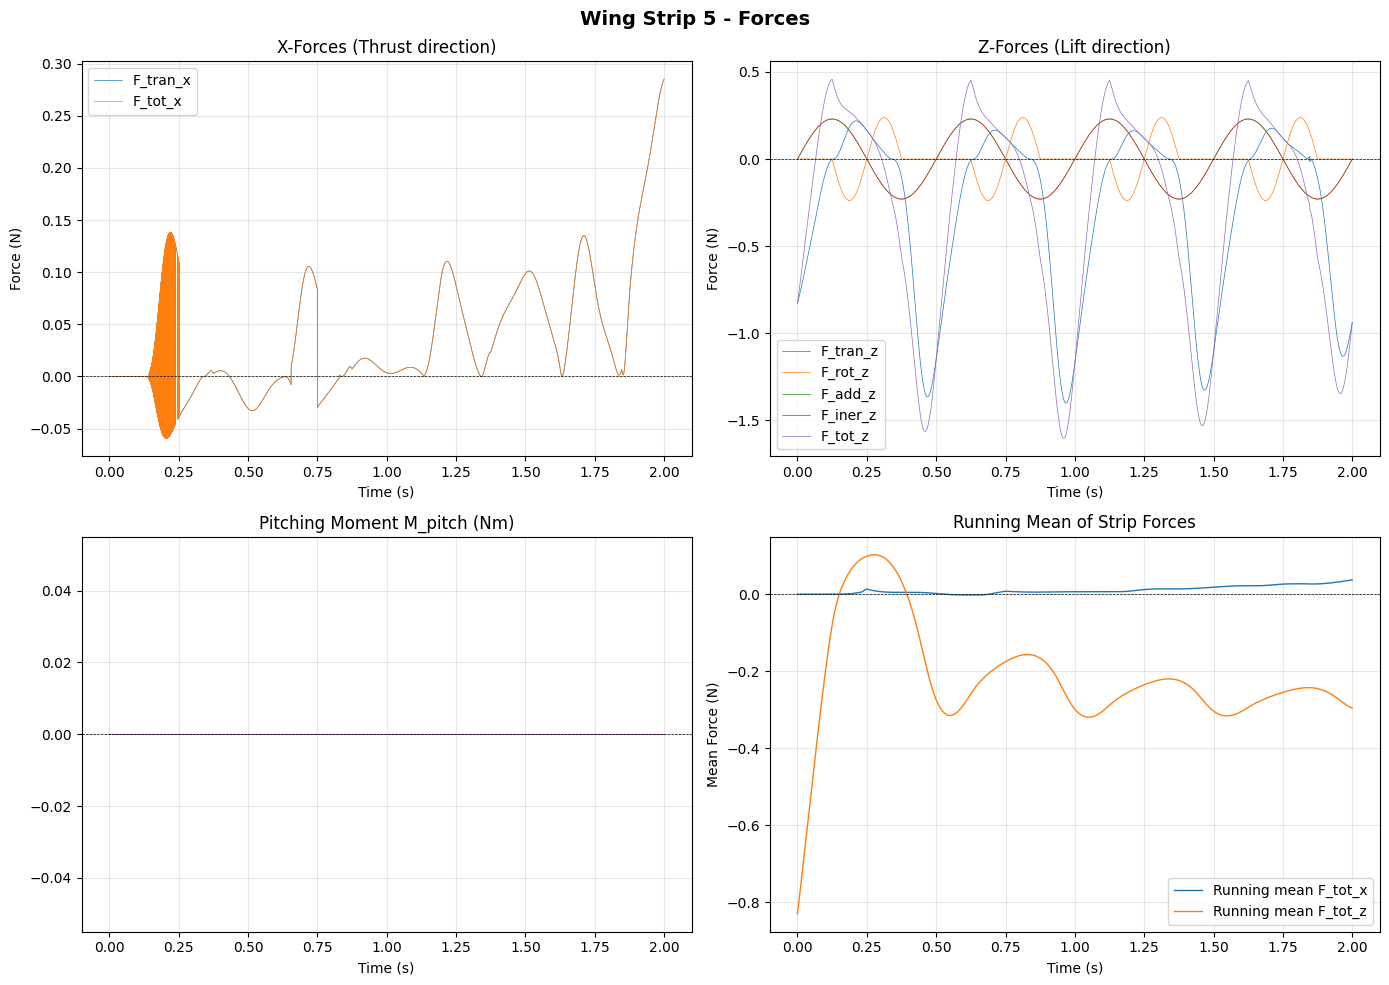

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Wing Strip {strip_idx} - Forces', fontsize=14, fontweight='bold')

# Plot X forces
ax = axes[0][0]
for col, lbl in [(f'{prefix}_F_tran_x', 'F_tran_x'), (f'{prefix}_F_tot_x', 'F_tot_x')]:
    if col in df.columns:
        ax.plot(df['time'], df[col], label=lbl, linewidth=0.5)
ax.set_title('X-Forces (Thrust direction)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Plot Z forces
ax = axes[0][1]
for col, lbl in [(f'{prefix}_F_tran_z', 'F_tran_z'), (f'{prefix}_F_rot_z', 'F_rot_z'),
                  (f'{prefix}_F_add_z', 'F_add_z'), (f'{prefix}_F_iner_z', 'F_iner_z'),
                  (f'{prefix}_F_tot_z', 'F_tot_z')]:
    if col in df.columns:
        ax.plot(df['time'], df[col], label=lbl, linewidth=0.5)
ax.set_title('Z-Forces (Lift direction)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Pitch Moment
ax = axes[1][0]
col = f'{prefix}_M_pitch'
if col in df.columns:
    ax.plot(df['time'], df[col], linewidth=0.5, color='purple')
ax.set_title('Pitching Moment M_pitch (Nm)')
ax.set_xlabel('Time (s)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Mean F_tot_x per flap cycle
ax = axes[1][1]
col_fx = f'{prefix}_F_tot_x'
col_fz = f'{prefix}_F_tot_z'
if col_fx in df.columns and col_fz in df.columns:
    ax.plot(df['time'], df[col_fx].cumsum() / (df.index + 1), label='Running mean F_tot_x', linewidth=1)
    ax.plot(df['time'], df[col_fz].cumsum() / (df.index + 1), label='Running mean F_tot_z', linewidth=1)
    ax.set_title('Running Mean of Strip Forces')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mean Force (N)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('../plot/strip_forces.png', dpi=150)
plt.show()

---
## 7. All 10 Strips - Total X Force (Thrust)
Compare thrust generation across the wingspan.

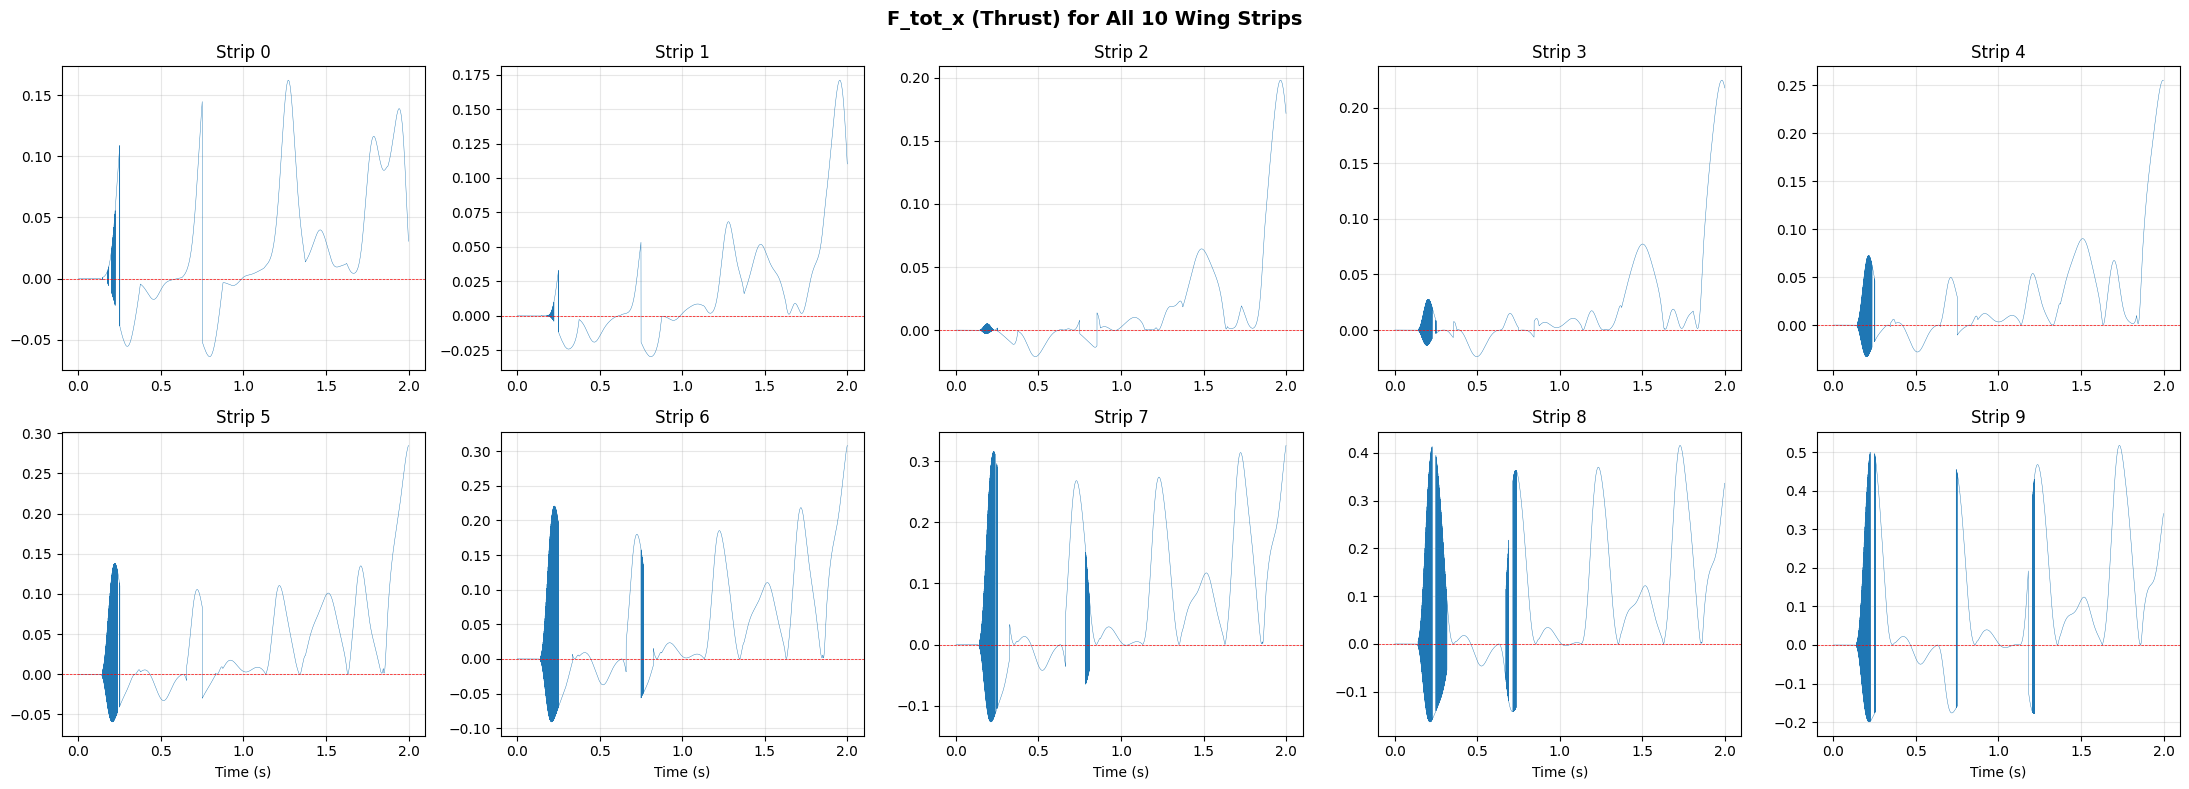

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('F_tot_x (Thrust) for All 10 Wing Strips', fontsize=14, fontweight='bold')

for i in range(10):
    ax = axes[i // 5][i % 5]
    col = f'strip_l_{i}_F_tot_x'
    if col in df.columns:
        ax.plot(df['time'], df[col], linewidth=0.3)
        ax.set_title(f'Strip {i}')
        ax.axhline(y=0, color='r', linestyle='--', linewidth=0.5)
    else:
        ax.set_title(f'Strip {i} - N/A')
    ax.grid(True, alpha=0.3)
    if i >= 5:
        ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('../plot/all_strips_Fx.png', dpi=150)
plt.show()

---
## 8. All 10 Strips - Total Z Force (Lift)
Compare lift generation across the wingspan.

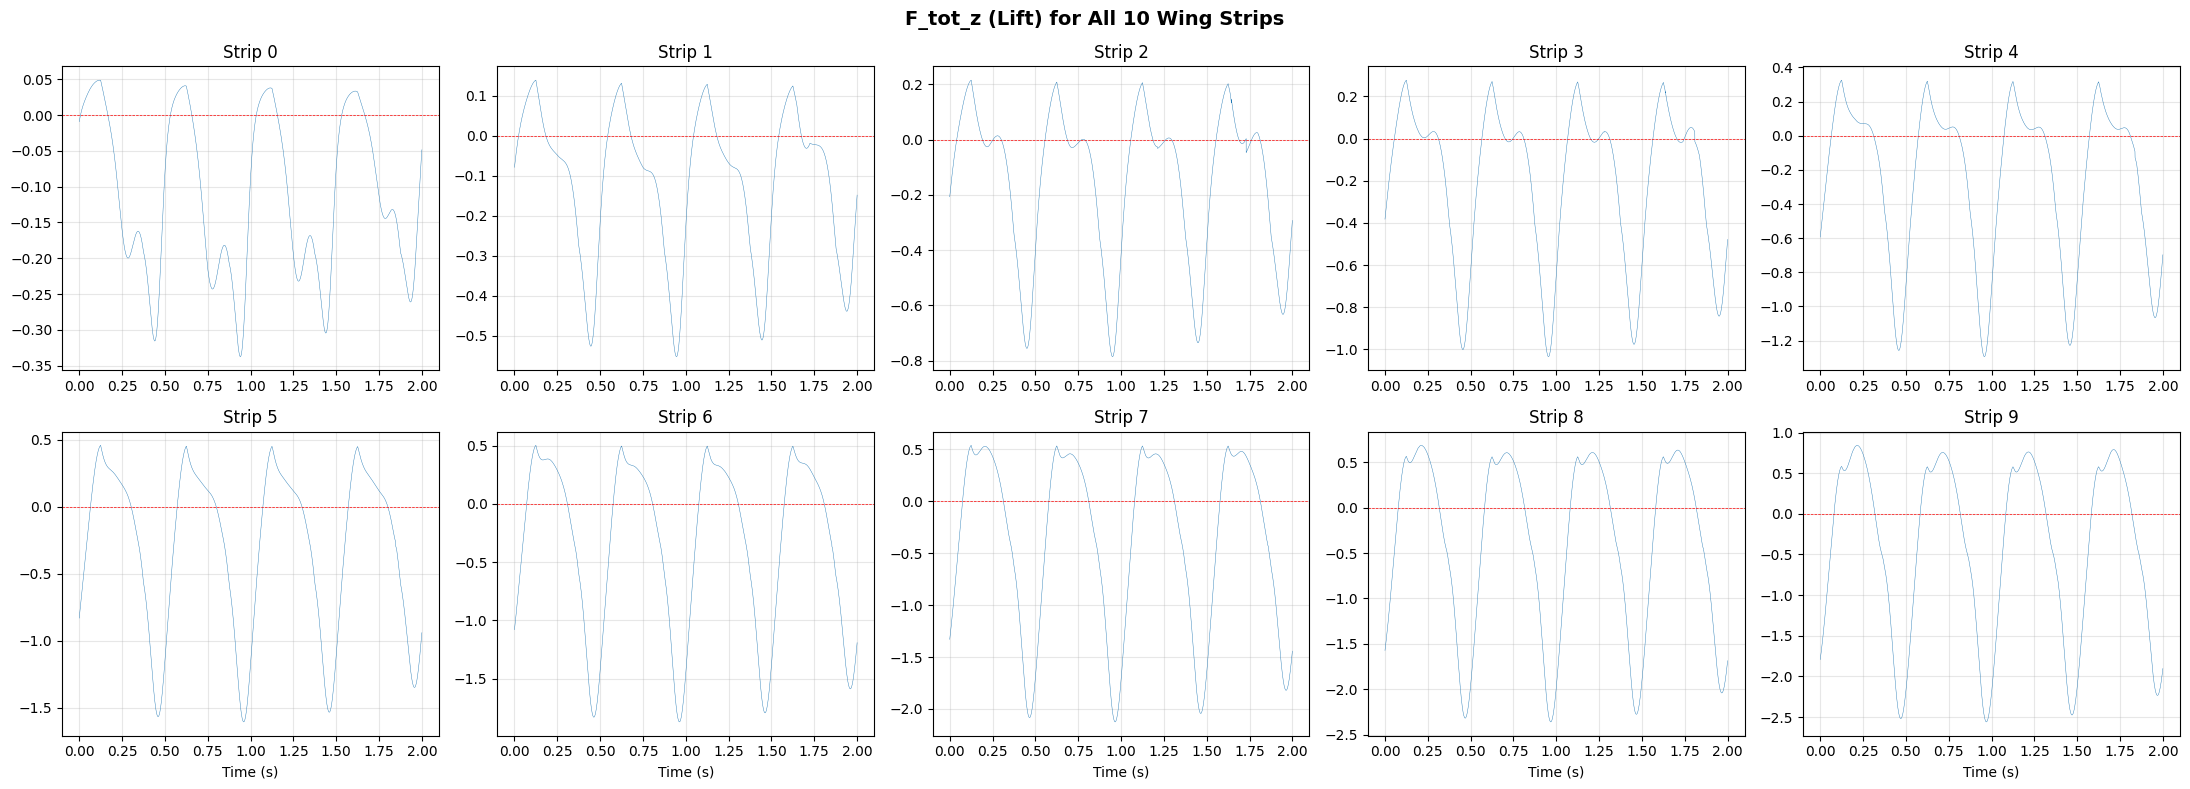

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('F_tot_z (Lift) for All 10 Wing Strips', fontsize=14, fontweight='bold')

for i in range(10):
    ax = axes[i // 5][i % 5]
    col = f'strip_l_{i}_F_tot_z'
    if col in df.columns:
        ax.plot(df['time'], df[col], linewidth=0.3)
        ax.set_title(f'Strip {i}')
        ax.axhline(y=0, color='r', linestyle='--', linewidth=0.5)
    else:
        ax.set_title(f'Strip {i} - N/A')
    ax.grid(True, alpha=0.3)
    if i >= 5:
        ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('../plot/all_strips_Fz.png', dpi=150)
plt.show()

---
## 9. Stroke-Phase Analysis
Overlaying flap_rate with body_force_x and body_vel_x to see which stroke phase generates thrust.

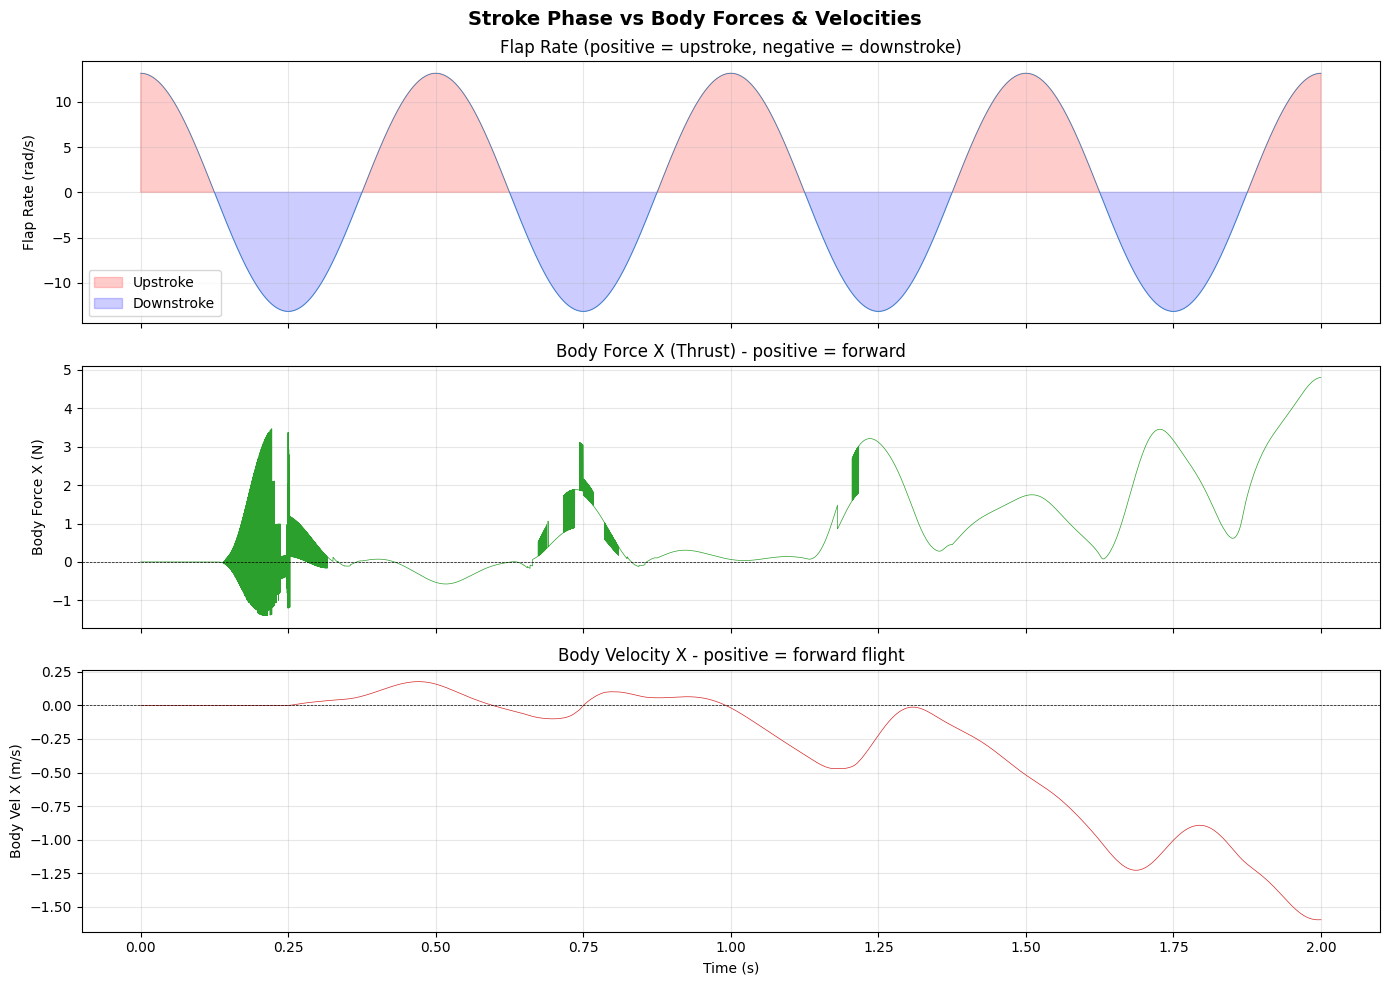

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Stroke Phase vs Body Forces & Velocities', fontsize=14, fontweight='bold')

# Flap rate
ax = axes[0]
if 'flap_rate' in df.columns:
    ax.plot(df['time'], df['flap_rate'], linewidth=0.5, color='tab:blue')
    ax.fill_between(df['time'], 0, df['flap_rate'], where=df['flap_rate'] > 0,
                     alpha=0.2, color='red', label='Upstroke')
    ax.fill_between(df['time'], 0, df['flap_rate'], where=df['flap_rate'] <= 0,
                     alpha=0.2, color='blue', label='Downstroke')
ax.set_ylabel('Flap Rate (rad/s)')
ax.set_title('Flap Rate (positive = upstroke, negative = downstroke)')
ax.legend()
ax.grid(True, alpha=0.3)

# Body force X
ax = axes[1]
if 'body_force_x' in df.columns:
    ax.plot(df['time'], df['body_force_x'], linewidth=0.5, color='tab:green')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Body Force X (N)')
ax.set_title('Body Force X (Thrust) - positive = forward')
ax.grid(True, alpha=0.3)

# Body vel X
ax = axes[2]
if 'body_vel_x' in df.columns:
    ax.plot(df['time'], df['body_vel_x'], linewidth=0.5, color='tab:red')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Body Vel X (m/s)')
ax.set_title('Body Velocity X - positive = forward flight')
ax.set_xlabel('Time (s)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plot/stroke_phase_analysis.png', dpi=150)
plt.show()

---
## 10. Summary Statistics

In [33]:
print('=== KEY SUMMARY ===')
for col in ['body_vel_x', 'body_vel_z', 'body_force_x', 'body_force_z',
            'body_pos_x', 'body_pos_z', 'body_pitch']:
    if col in df.columns:
        print(f'{col:20s} | mean={df[col].mean():+10.4f} | min={df[col].min():+10.4f} | max={df[col].max():+10.4f}')
print()
print('=== STRIP 5 FORCE MEANS ===')
for sfx in ['F_tran_x', 'F_tran_z', 'F_rot_z', 'F_add_z', 'F_iner_z', 'F_tot_x', 'F_tot_z']:
    col = f'strip_l_5_{sfx}'
    if col in df.columns:
        print(f'{sfx:15s} | mean={df[col].mean():+10.6f} | min={df[col].min():+10.6f} | max={df[col].max():+10.6f}')

=== KEY SUMMARY ===
body_vel_x           | mean=   -0.3125 | min=   -1.5978 | max=   +0.1775
body_vel_z           | mean=   +1.9722 | min=   -0.4086 | max=   +3.7844
body_force_x         | mean=   +0.8620 | min=   -1.3996 | max=   +4.8060
body_force_z         | mean=   -4.7606 | min=  -26.4422 | max=   +4.4085
body_pos_x           | mean=   -0.0799 | min=   -0.6251 | max=   +0.0351
body_pos_z           | mean=   +1.8604 | min=   -0.0246 | max=   +3.9445
body_pitch           | mean=   -0.3967 | min=   -1.1026 | max=   +0.0003

=== STRIP 5 FORCE MEANS ===
F_tran_x        | mean= +0.037316 | min= -0.059254 | max= +0.284921
F_tran_z        | mean= -0.296012 | min= -1.401816 | max= +0.219638
F_rot_z         | mean= -0.000000 | min= -0.238406 | max= +0.238406
F_add_z         | mean= +0.000000 | min= -0.230786 | max= +0.230786
F_iner_z        | mean= +0.000000 | min= -0.229418 | max= +0.229418
F_tot_x         | mean= +0.037316 | min= -0.059254 | max= +0.284921
F_tot_z         | mean= -0.29601